In [22]:
import pandas as pd

In [23]:
df = pd.read_csv(r"C:\Users\MY PC\Desktop\ML\projects\titanic\Titanic-Dataset.csv")

# How big is the data

In [24]:
df.shape

(891, 12)

# How does the data looks like

In [25]:
# df.head()
df.sample(5) # random data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
250,251,0,3,"Reed, Mr. James George",male,NaN,0,0,362316,7.250,NaN,S
714,715,0,2,"Greenberg, Mr. Samuel",male,52.0,0,0,250647,13.000,NaN,S
283,284,1,3,"Dorking, Mr. Edward Arthur",male,19.0,0,0,A/5. 10482,8.050,NaN,S
260,261,0,3,"Smith, Mr. Thomas",male,NaN,0,0,384461,7.750,NaN,Q
682,683,0,3,"Olsvigen, Mr. Thor Anderson",male,20.0,0,0,6563,9.225,NaN,S


# What is the data type cols

In [26]:
# df.dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Are there any missing values?

In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# How does the data look mathematically?

In [28]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Are there duplicate values?

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.corr(numeric_only=True)['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

# Univariate Analyis

# 1. Categorical Data

# a. Countplot

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
37,38,0,3,"Cann, Mr. Ernest Charles",male,21.0,0,0,A./5. 2152,8.0500,NaN,S
215,216,1,1,"Newell, Miss. Madeleine",female,31.0,1,0,35273,113.2750,D36,C
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6000,A16,C
72,73,0,2,"Hood, Mr. Ambrose Jr",male,21.0,0,0,S.O.C. 14879,73.5000,NaN,S


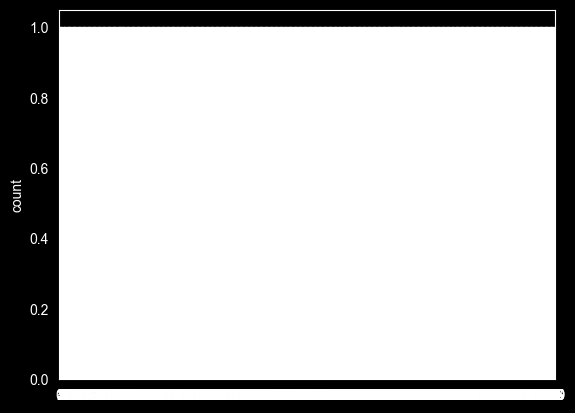

In [33]:
sns.countplot(df['Survived'])
plt.show()

In [34]:
print(df['Survived'].head())
print(df['Survived'].value_counts())

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64


<Axes: xlabel='Embarked', ylabel='count'>

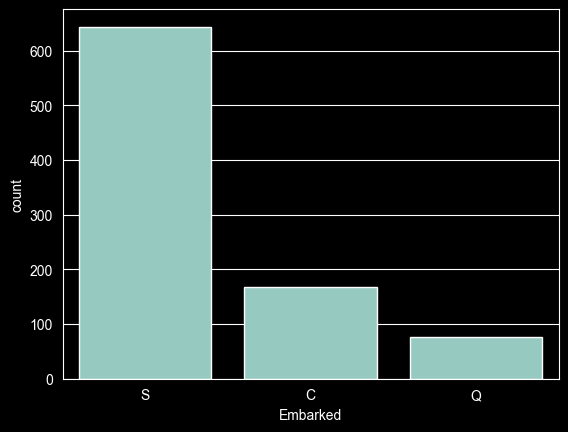

In [35]:
sns.countplot(x='Embarked', data=df)

# b. PieChart

<Axes: >

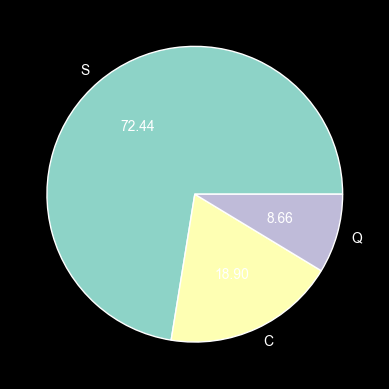

In [36]:
df['Embarked'].value_counts().plot(kind='pie', autopct='%.2f')

# 2. Numerical Data

# a. Histogram

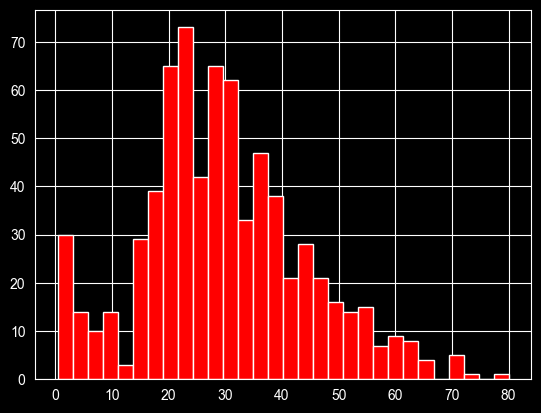

In [37]:
plt.hist(df['Age'], color='red', bins=30)
plt.show()

# b. Distplot

C:\Users\MY PC\AppData\Local\Temp\ipykernel_26076\1599895865.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


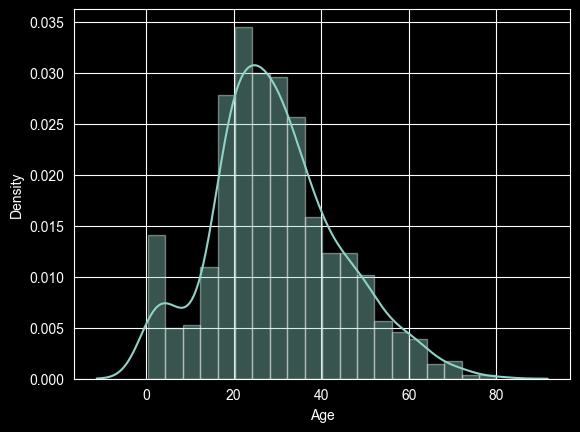

In [38]:
sns.distplot(df['Age'])
plt.show()

# c. Boxplot

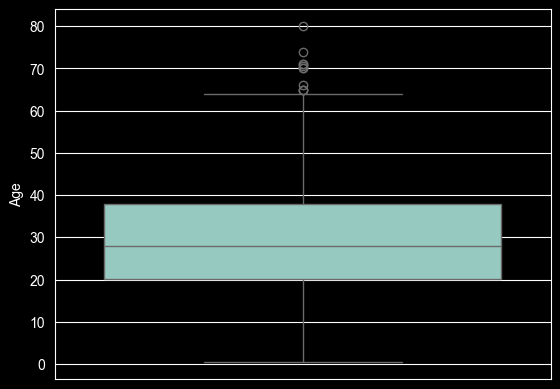

In [39]:
# use when it has noise and outliers
sns.boxplot(df['Age'])
plt.show()

In [40]:
df['Age'].skew()

np.float64(0.38910778230082704)

# Pipeline